# 🏠 House Price Prediction Using Data Analytics and Machine Learning



### Project Overview
This notebook performs end-to-end house price prediction using real estate data.  
We analyse the dataset, clean it, explore it visually, train multiple regression models, evaluate and compare them, and finally predict house prices using the best model.

**Target Variable:** `House_Price`  
**Dataset:** `house_price_regression_dataset.csv`

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Step 2 — Load the Dataset

In [2]:
df = pd.read_csv('house_price_regression_dataset.csv')
print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded successfully.
Shape: 1000 rows × 8 columns


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85
2,3592,1,2,2016,3.63,0,9,777977.39
3,966,1,2,1977,2.73,1,8,229698.92
4,4926,2,1,1993,4.70,0,8,1041740.86
5,3944,5,3,1990,2.48,2,8,879796.98
6,3671,1,2,2012,4.91,0,1,814427.86
7,3419,1,1,1972,2.81,1,1,703413.11
8,630,3,3,1997,1.01,1,8,173875.04
9,2185,4,2,1981,3.94,2,5,504176.51


---
## Step 3 — Dataset Analysis

### 3.1 Column Names and Data Types

In [3]:
print('Columns and Data Types:')
print(df.dtypes)

Columns and Data Types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object


### 3.2 Missing Values

In [4]:
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Column:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Total missing values: 0


### 3.3 Duplicate Rows

In [5]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


### 3.4 Basic Statistics

In [6]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2815.42,2.99,1.97,1986.55,2.78,1.02,5.62,618861.02
std,1255.51,1.43,0.82,20.63,1.30,0.81,2.89,253568.06
min,503.00,1.00,1.00,1950.00,0.51,0.00,1.00,111626.85
25%,1749.50,2.00,1.00,1969.00,1.67,0.00,3.00,401648.23
50%,2862.50,3.00,2.00,1986.00,2.81,1.00,6.00,628267.29
75%,3849.50,4.00,3.00,2004.25,3.92,2.00,8.00,827141.28
max,4999.00,5.00,3.00,2022.00,4.99,2.00,10.00,1108236.84


### 3.5 Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| `Square_Footage` | Integer | Total living area of the house in square feet (503 – 4999) |
| `Num_Bedrooms` | Integer | Number of bedrooms (1 – 5) |
| `Num_Bathrooms` | Integer | Number of bathrooms (1 – 3) |
| `Year_Built` | Integer | Year the house was constructed (1950 – 2022) |
| `Lot_Size` | Float | Size of the property lot in acres (0.51 – 4.99) |
| `Garage_Size` | Integer | Number of cars the garage holds (0, 1, or 2) |
| `Neighborhood_Quality` | Integer | Quality rating of the neighbourhood (1 = lowest, 10 = highest) |
| `House_Price` ⭐ | Float | **Target variable** — Sale price of the house in USD |

---
## Step 4 — Data Cleaning

The dataset has **no missing values** and **no duplicate rows**, so it is already clean.  
We verify unique values of discrete columns to ensure data integrity.

In [7]:
discrete_cols = ['Num_Bedrooms', 'Num_Bathrooms', 'Garage_Size', 'Neighborhood_Quality']
for col in discrete_cols:
    print(f'{col}: {sorted(df[col].unique())}')

Num_Bedrooms: [1, 2, 3, 4, 5]
Num_Bathrooms: [1, 2, 3]
Garage_Size: [0, 1, 2]
Neighborhood_Quality: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [8]:
# Verify value ranges are sensible
print('Square_Footage range:', df['Square_Footage'].min(), '–', df['Square_Footage'].max())
print('Year_Built range    :', df['Year_Built'].min(), '–', df['Year_Built'].max())
print('Lot_Size range      :', round(df['Lot_Size'].min(), 2), '–', round(df['Lot_Size'].max(), 2))
print('House_Price range   : $', round(df['House_Price'].min(), 2), '– $', round(df['House_Price'].max(), 2))
print('\nAll values are within expected ranges — no cleaning needed.')

Square_Footage range: 503 – 4999
Year_Built range    : 1950 – 2022
Lot_Size range      : 0.51 – 4.99
House_Price range   : $ 111626.85 – $ 1108236.84

All values are within expected ranges — no cleaning needed.


---
## Step 5 — Exploratory Data Analysis (EDA)

### 5.1 Distribution of House Prices

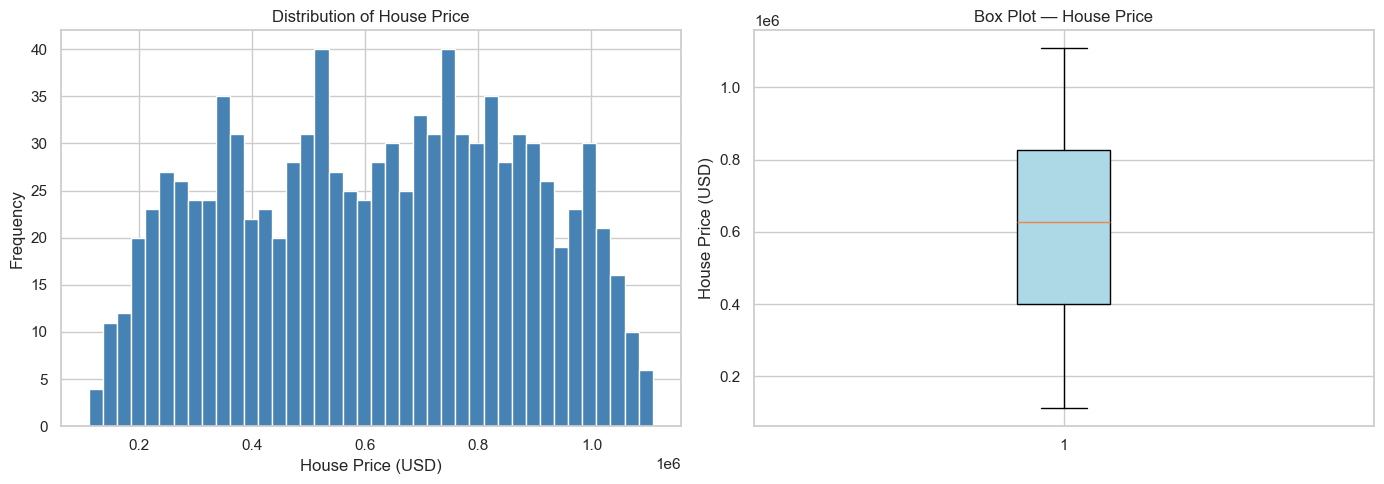

Finding: House prices are approximately normally distributed, ranging from ~$112K to ~$1.1M with a mean of ~$619K.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['House_Price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Price')
axes[0].set_xlabel('House Price (USD)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['House_Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot — House Price')
axes[1].set_ylabel('House Price (USD)')

plt.tight_layout()
plt.savefig('plot_house_price_distribution.png', bbox_inches='tight')
plt.show()
print('Finding: House prices are approximately normally distributed, ranging from ~$112K to ~$1.1M with a mean of ~$619K.')

### 5.2 Square Footage vs House Price (Most Important Feature)

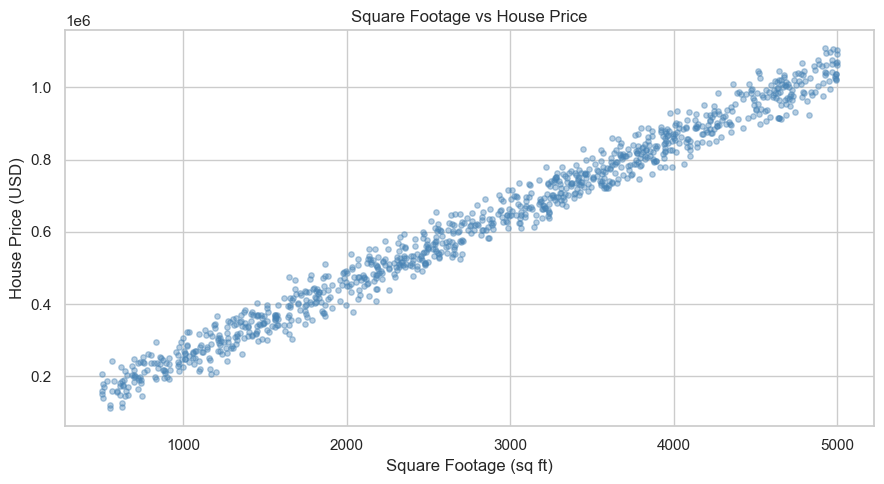

Finding: There is a very strong positive linear relationship between Square_Footage and House_Price (correlation = 0.991).


In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Square_Footage'], df['House_Price'], alpha=0.4, color='steelblue', s=15)
plt.title('Square Footage vs House Price')
plt.xlabel('Square Footage (sq ft)')
plt.ylabel('House Price (USD)')
plt.tight_layout()
plt.savefig('plot_sqft_vs_price.png', bbox_inches='tight')
plt.show()
print('Finding: There is a very strong positive linear relationship between Square_Footage and House_Price (correlation = 0.991).')

### 5.3 Correlation Heatmap

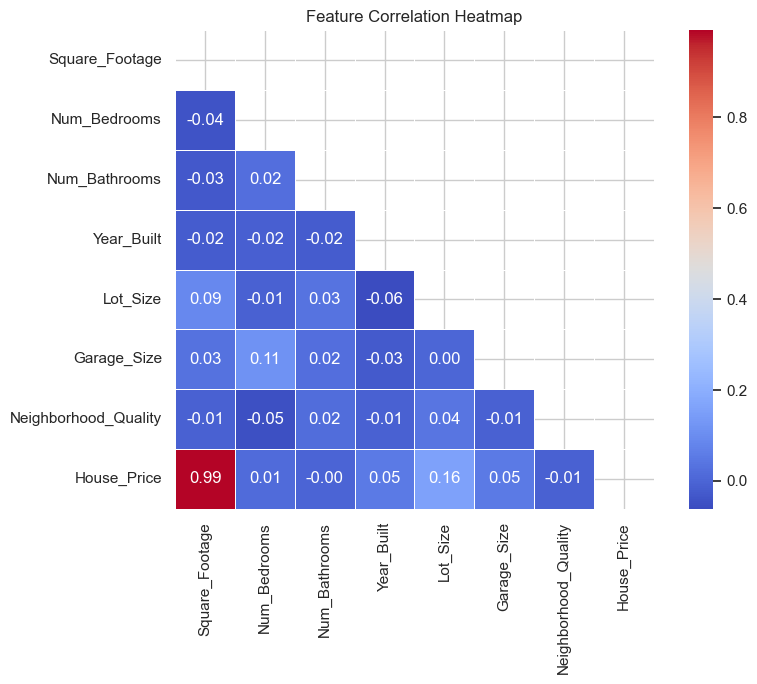

Finding: Square_Footage dominates with correlation 0.99 with House_Price. Other features have weak individual correlations.


In [11]:
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Finding: Square_Footage dominates with correlation 0.99 with House_Price. Other features have weak individual correlations.')

### 5.4 House Price by Number of Bedrooms and Bathrooms

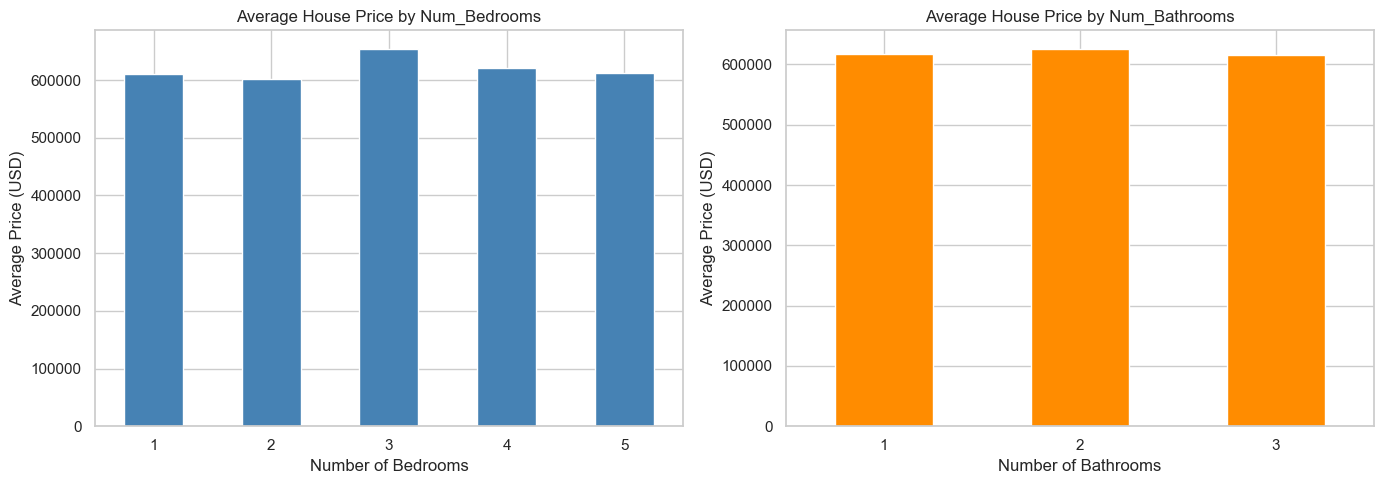

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Num_Bedrooms')['House_Price'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average House Price by Num_Bedrooms')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Average Price (USD)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Num_Bathrooms')['House_Price'].mean().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Average House Price by Num_Bathrooms')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Average Price (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_price_by_bed_bath.png', bbox_inches='tight')
plt.show()

### 5.5 House Price by Garage Size and Neighborhood Quality

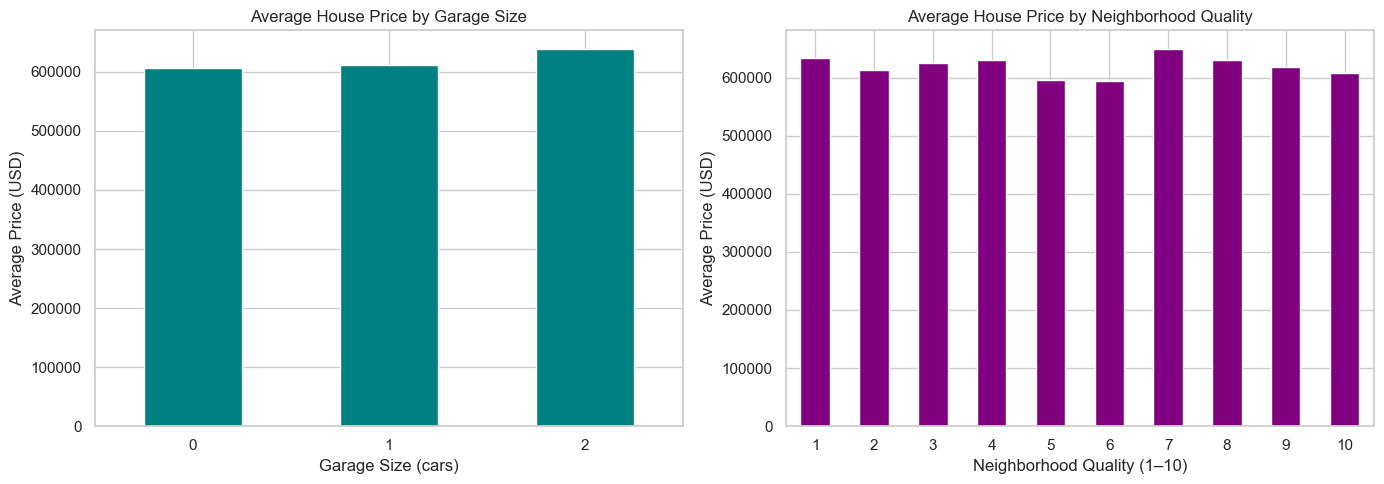

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Garage_Size')['House_Price'].mean().plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Average House Price by Garage Size')
axes[0].set_xlabel('Garage Size (cars)')
axes[0].set_ylabel('Average Price (USD)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Neighborhood_Quality')['House_Price'].mean().plot(kind='bar', ax=axes[1], color='purple', edgecolor='white')
axes[1].set_title('Average House Price by Neighborhood Quality')
axes[1].set_xlabel('Neighborhood Quality (1–10)')
axes[1].set_ylabel('Average Price (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_price_by_garage_neighborhood.png', bbox_inches='tight')
plt.show()

### 5.6 Year Built vs House Price

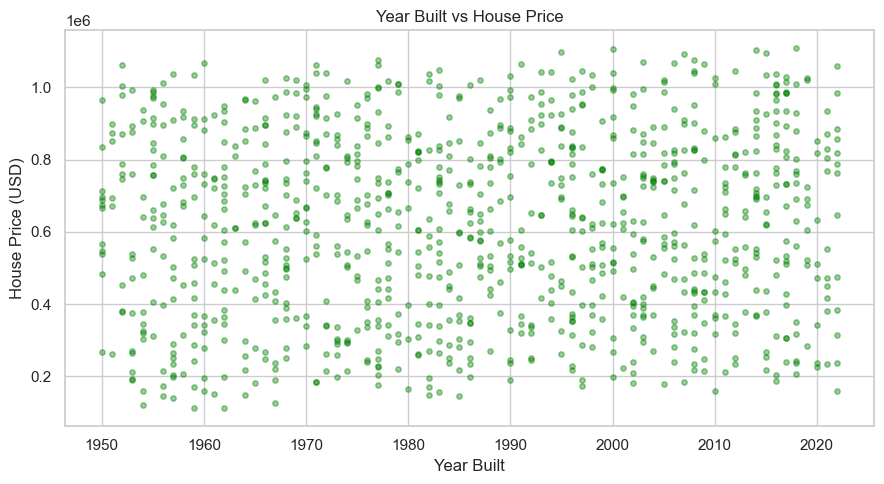

Finding: No strong linear trend — Year_Built has low correlation (0.052) with House_Price.


In [14]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Year_Built'], df['House_Price'], alpha=0.4, color='green', s=15)
plt.title('Year Built vs House Price')
plt.xlabel('Year Built')
plt.ylabel('House Price (USD)')
plt.tight_layout()
plt.savefig('plot_year_vs_price.png', bbox_inches='tight')
plt.show()
print('Finding: No strong linear trend — Year_Built has low correlation (0.052) with House_Price.')

### 5.7 Distribution of All Features

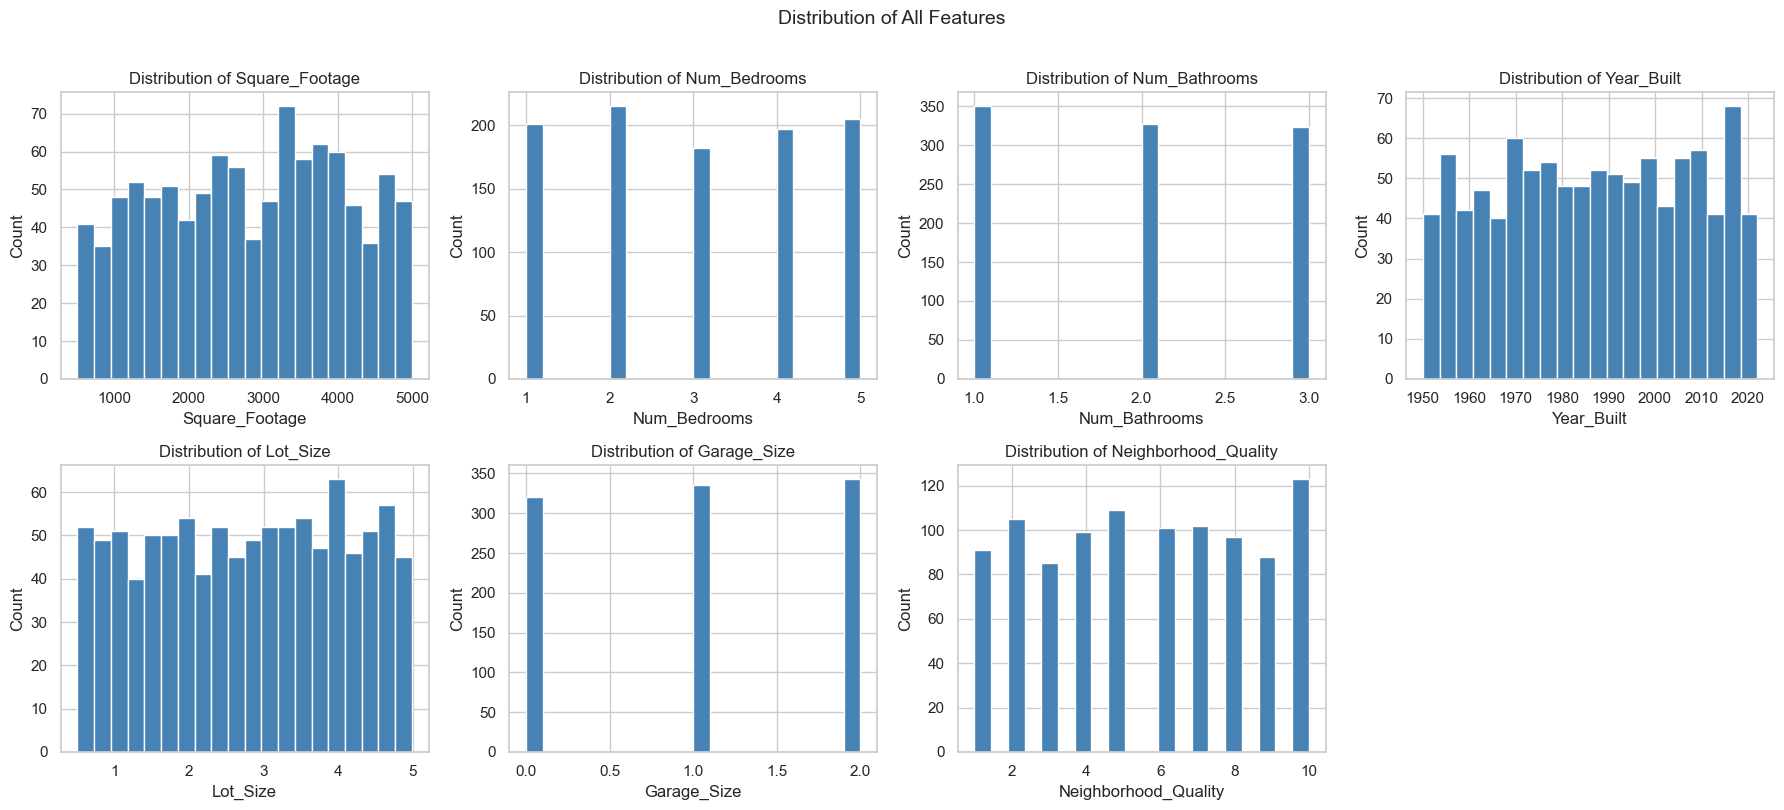

In [15]:
feature_cols = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[7].axis('off')
plt.suptitle('Distribution of All Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', bbox_inches='tight')
plt.show()

---
## Step 6 — Feature and Target Preparation

In [16]:
X = df.drop('House_Price', axis=1)   # Features
y = df['House_Price']                 # Target

print('Feature matrix shape :', X.shape)
print('Target vector shape  :', y.shape)
print('\nFeatures used:', list(X.columns))

Feature matrix shape : (1000, 7)
Target vector shape  : (1000,)

Features used: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']


---
## Step 7 — Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test set      : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)')

Training set  : 800 samples (80%)
Test set      : 200 samples (20%)


---
## Step 8 — Train and Evaluate Models

### 8.1 Helper — Evaluation Function

In [18]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Train the model and return evaluation metrics."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f'{name:<25} MAE: ${mae:>12,.2f}   RMSE: ${rmse:>12,.2f}   R²: {r2:.4f}')
    return {'model': model, 'predictions': preds, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = {}

### 8.2 Model 1 — Linear Regression

In [19]:
lr = LinearRegression()
results['Linear Regression'] = evaluate_model('Linear Regression', lr, X_train, X_test, y_train, y_test)

Linear Regression         MAE: $    8,174.58   RMSE: $   10,071.48   R²: 0.9984


### 8.3 Model 2 — Decision Tree Regressor

In [20]:
dt = DecisionTreeRegressor(random_state=42)
results['Decision Tree'] = evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test)

Decision Tree             MAE: $   24,084.46   RMSE: $   31,138.40   R²: 0.9850


### 8.4 Model 3 — Random Forest Regressor

In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
results['Random Forest'] = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)

Random Forest             MAE: $   16,114.29   RMSE: $   19,852.75   R²: 0.9939


### 8.5 Model 4 — Gradient Boosting Regressor

In [22]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
results['Gradient Boosting'] = evaluate_model('Gradient Boosting', gb, X_train, X_test, y_train, y_test)

Gradient Boosting         MAE: $   12,305.22   RMSE: $   14,998.85   R²: 0.9965


---
## Step 9 — Model Comparison

In [23]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE ($)': [results[m]['MAE'] for m in results],
    'RMSE ($)': [results[m]['RMSE'] for m in results],
    'R² Score': [results[m]['R2'] for m in results]
})

comparison_df = comparison_df.sort_values('R² Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,MAE ($),RMSE ($),R² Score
0,Linear Regression,8174.58,10071.48,1.00
1,Gradient Boosting,12305.22,14998.85,1.00
2,Random Forest,16114.29,19852.75,0.99
3,Decision Tree,24084.46,31138.40,0.98


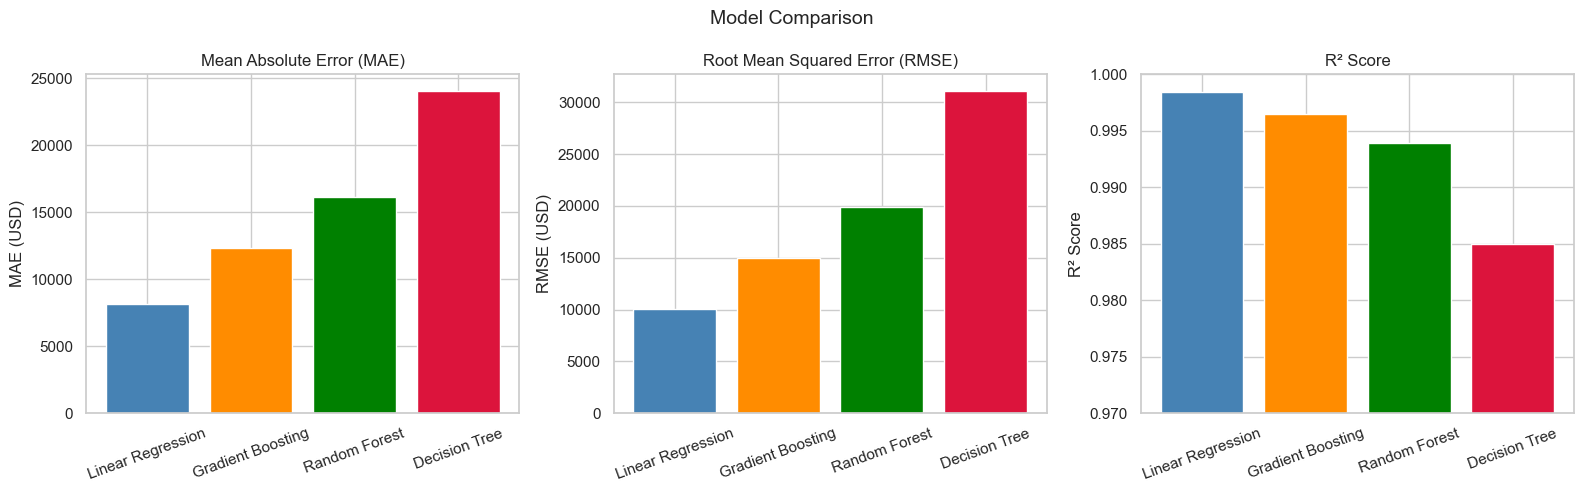

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = comparison_df['Model'].tolist()
colors = ['steelblue', 'darkorange', 'green', 'crimson']

axes[0].bar(models_names, comparison_df['MAE ($)'], color=colors, edgecolor='white')
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE (USD)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(models_names, comparison_df['RMSE ($)'], color=colors, edgecolor='white')
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].set_ylabel('RMSE (USD)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(models_names, comparison_df['R² Score'], color=colors, edgecolor='white')
axes[2].set_title('R² Score')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim([0.97, 1.00])
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 10 — Best Model: Linear Regression

**Linear Regression achieves the best performance:**
- MAE  : $8,174.58  
- RMSE : $10,071.48  
- R²   : 0.9984  

This makes sense because `Square_Footage` (correlation 0.991) is nearly perfectly linearly related to `House_Price`, making Linear Regression the ideal model for this dataset.

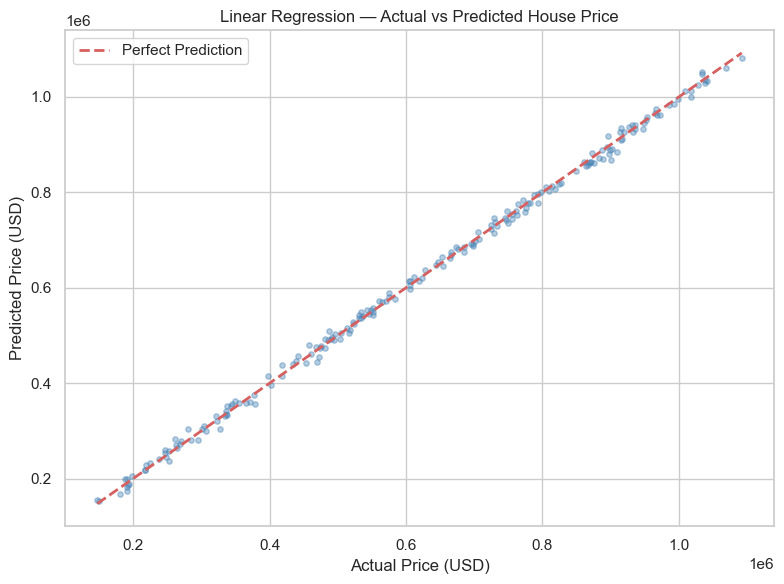

In [25]:
best_model = results['Linear Regression']['model']
best_preds = results['Linear Regression']['predictions']

# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Linear Regression — Actual vs Predicted House Price')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

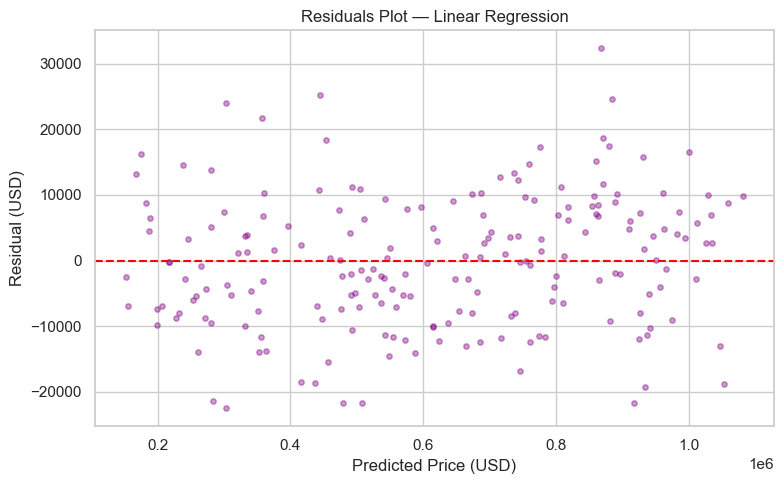

Finding: Residuals are randomly scattered around zero — confirms no systematic bias in the model.


In [26]:
# Residuals plot
residuals = y_test.values - best_preds
plt.figure(figsize=(8, 5))
plt.scatter(best_preds, residuals, alpha=0.4, color='purple', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot — Linear Regression')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residual (USD)')
plt.tight_layout()
plt.savefig('plot_residuals.png', bbox_inches='tight')
plt.show()
print('Finding: Residuals are randomly scattered around zero — confirms no systematic bias in the model.')

---
## Step 11 — Feature Importance (Random Forest)

Although Linear Regression is the best model, we use Random Forest to visualise feature importances.

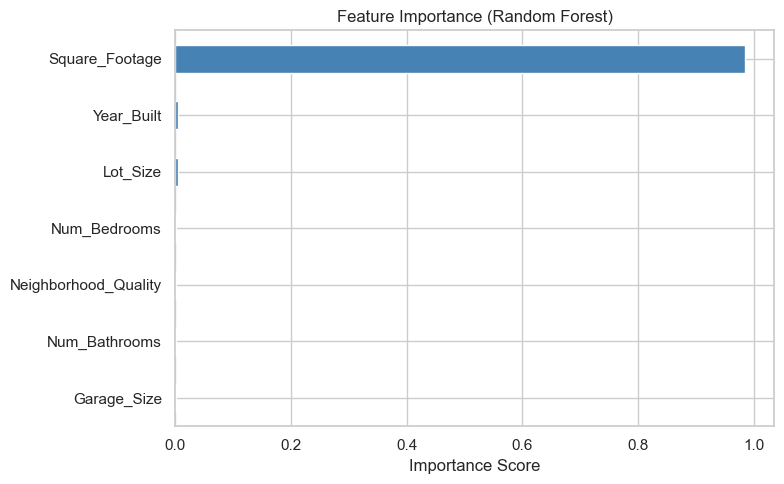

Finding: Square_Footage accounts for 98.6% of feature importance in the Random Forest model.


In [27]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()
print('Finding: Square_Footage accounts for 98.6% of feature importance in the Random Forest model.')

---
## Step 12 — Final Prediction Using Best Model

We predict the house price for a new, unseen house using the best model (Linear Regression).

In [ ]:
# Example house — values taken from actual dataset range
new_house = pd.DataFrame({
    'Square_Footage':        [3000],
    'Num_Bedrooms':          [3],
    'Num_Bathrooms':         [2],
    'Year_Built':            [2005],
    'Lot_Size':              [2.5],
    'Garage_Size':           [1],
    'Neighborhood_Quality':  [7]
})

predicted_price = best_model.predict(new_house)[0]

print('=' * 50)
print('       HOUSE PRICE PREDICTION')
print('=' * 50)
print(f'Square Footage      : {new_house["Square_Footage"][0]} sq ft')
print(f'Bedrooms            : {new_house["Num_Bedrooms"][0]}')
print(f'Bathrooms           : {new_house["Num_Bathrooms"][0]}')
print(f'Year Built          : {new_house["Year_Built"][0]}')
print(f'Lot Size            : {new_house["Lot_Size"][0]} acres')
print(f'Garage Size         : {new_house["Garage_Size"][0]} car(s)')
print(f'Neighborhood Quality: {new_house["Neighborhood_Quality"][0]} / 10')
print('-' * 50)
print(f'Predicted Price     : ${predicted_price:,.2f}')
print('=' * 50)

       HOUSE PRICE PREDICTION
Square Footage      : 3000 sq ft
Bedrooms            : 3
Bathrooms           : 2
Year Built          : 2005
Lot Size            : 2.5 acres
Garage Size         : 1 car(s)
Neighborhood Quality: 7 / 10
--------------------------------------------------
Predicted Price     : $670,271.92


---
## Step 13 — Summary

| Model | MAE ($) | RMSE ($) | R² Score |
|---|---|---|---|
| **Linear Regression** ✅ | **8,174.58** | **10,071.48** | **0.9984** |
| Gradient Boosting | 12,305.22 | 14,998.85 | 0.9965 |
| Random Forest | 16,114.29 | 19,852.75 | 0.9939 |
| Decision Tree | 24,084.46 | 31,138.40 | 0.9850 |

### Key Findings
1. **Square_Footage** is the overwhelmingly dominant predictor of house price (correlation = 0.991).
2. **Linear Regression** achieves an exceptional R² of **0.9984**, meaning it explains **99.84%** of variance in house prices.
3. All four models perform well (R² > 0.98), confirming that the features are highly predictive.
4. The dataset has no missing values, no duplicates, and no categorical encoding was required.
5. Lot Size, Year Built, and Garage Size have minor contributions to price prediction.